## UCAP STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

ucap=pd.read_csv('../stock_data/ucap.csv') ## so it can be small letter. This is cool.
ucap=ucap.drop(columns=['high_price','low_price'])
ucap.rename(columns={'trade_date':'date'},inplace=True)
ucap['date']=pd.to_datetime(ucap['date'])
ucap['month']=ucap['date'].dt.month
ucap['quarter']=ucap['date'].dt.quarter
ucap['year']=ucap['date'].dt.year

ucap

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42829,UCAP,2017-01-03,2.81,2.81,7937852,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43389,UCAP,2017-01-04,2.89,2.89,6707200,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43499,UCAP,2017-01-05,2.88,2.88,11036822,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43609,UCAP,2017-01-06,3.02,3.02,8993317,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43699,UCAP,2017-01-09,3.31,3.31,19658337,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298146,UCAP,2026-07-13,17.75,17.75,5012859,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298584,UCAP,2026-07-14,17.75,17.75,2043880,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,299022,UCAP,2026-07-15,17.75,17.75,5432174,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299460,UCAP,2026-07-16,17.50,17.50,5366137,2026-07-16T15:10:03.113936+00:00,7,3,2026


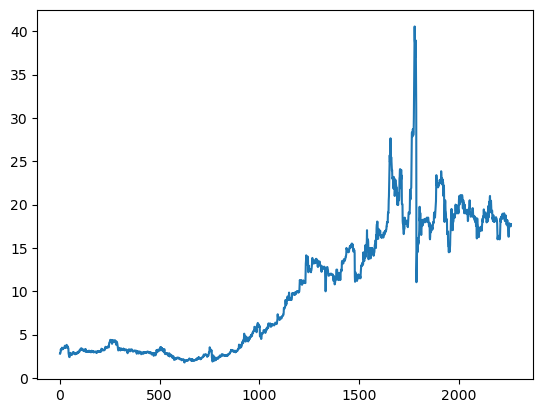

In [2]:
import matplotlib.pyplot as plt

plt.plot(ucap['close_price'])
plt.show()

In [3]:
ucap_end_month_df = (
    ucap
    .sort_values("date")
    .groupby(ucap["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

ucap_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45399,UCAP,2017-01-31,3.50,3.50,10116003,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47221,UCAP,2017-02-28,3.53,3.53,15691732,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49337,UCAP,2017-03-31,2.81,2.81,4964089,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51164,UCAP,2017-04-28,2.87,2.87,2463552,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53087,UCAP,2017-05-31,3.20,3.20,4678761,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35383,UCAP,2026-03-31,18.35,18.35,7731688,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281209,UCAP,2026-04-30,18.40,18.40,21446974,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284275,UCAP,2026-05-29,19.00,19.00,15993336,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294203,UCAP,2026-06-30,16.80,16.80,11113700,2026-06-30T15:10:03.08168+00:00,6,2,2026


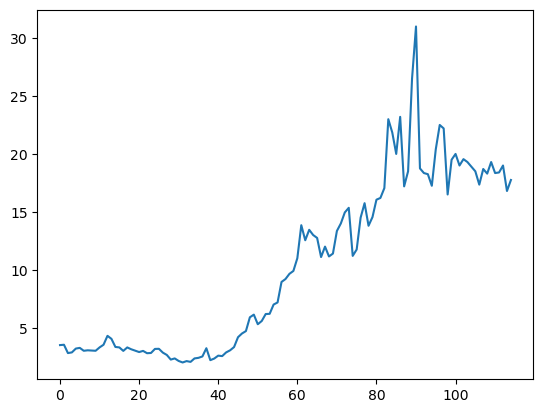

In [4]:
plt.plot(ucap_end_month_df['close_price'])
plt.show()

In [5]:
ucap_end_month_df['returns']=ucap_end_month_df['close_price'].pct_change()*100
ucap_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45399,UCAP,2017-01-31,3.50,3.50,10116003,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47221,UCAP,2017-02-28,3.53,3.53,15691732,2026-04-08T02:44:45.006295+00:00,2,1,2017,0.857143
2,49337,UCAP,2017-03-31,2.81,2.81,4964089,2026-04-08T02:45:42.281198+00:00,3,1,2017,-20.396601
3,51164,UCAP,2017-04-28,2.87,2.87,2463552,2026-04-08T02:51:55.619599+00:00,4,2,2017,2.135231
4,53087,UCAP,2017-05-31,3.20,3.20,4678761,2026-04-08T02:52:57.421655+00:00,5,2,2017,11.498258
...,...,...,...,...,...,...,...,...,...,...,...
110,35383,UCAP,2026-03-31,18.35,18.35,7731688,2026-03-31T15:00:02.085058+00:00,3,1,2026,-4.922280
111,281209,UCAP,2026-04-30,18.40,18.40,21446974,2026-04-30T15:00:02.170664+00:00,4,2,2026,0.272480
112,284275,UCAP,2026-05-29,19.00,19.00,15993336,2026-05-29T15:00:02.455558+00:00,5,2,2026,3.260870
113,294203,UCAP,2026-06-30,16.80,16.80,11113700,2026-06-30T15:10:03.08168+00:00,6,2,2026,-11.578947


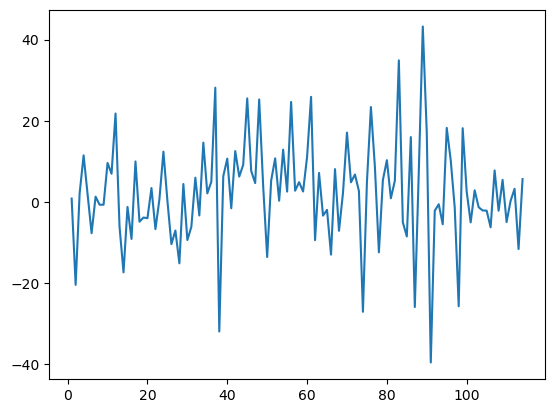

In [6]:
plt.plot(ucap_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(ucap_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(-9.773892847842669, 7.017849702626566e-17, 1, 112, {'1%': -3.4901313156261384, '5%': -2.8877122815688776, '10%': -2.5807296460459184}, 795.479820823501)
stationary


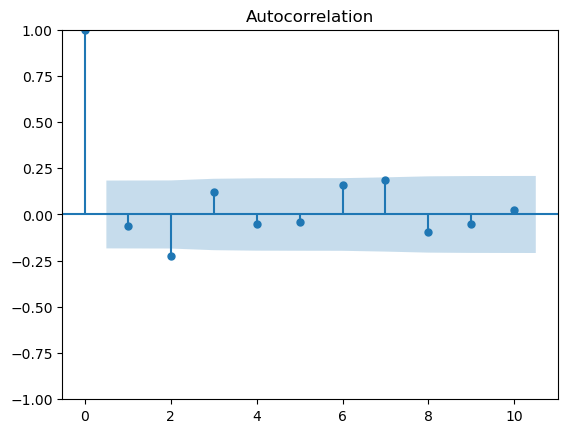

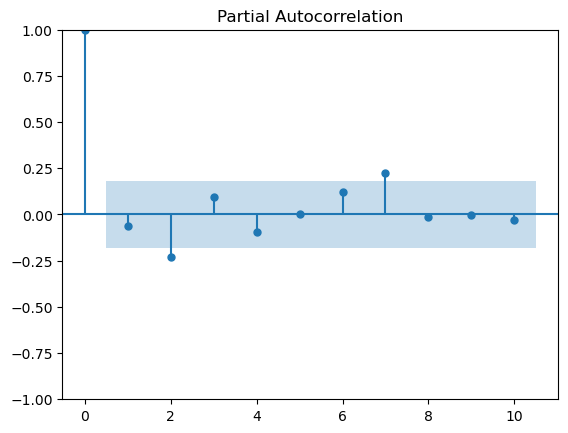

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(ucap_end_month_df['returns'].dropna(), lags=10)
plot_pacf(ucap_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=ucap_end_month_df['close_price'][:-10]
test=ucap_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -649.2369691355019]
[0, 0, 0, 0, 0, 1, -358.5510399694077]
[0, 0, 0, 0, 0, 2, -77.897827594251]
[0, 0, 0, 0, 1, 0, -7.332927007655179]
[0, 0, 0, 0, 1, 1, -6.9831947007499835]
[0, 0, 0, 0, 1, 2, -67.03864104922869]
[0, 0, 0, 0, 2, 0, -50.824564825585966]
[0, 0, 0, 0, 2, 1, -27.64964341972525]
[0, 0, 0, 0, 2, 2, -34.553980608014726]
[0, 0, 0, 1, 0, 0, -3.739369721575419]
[0, 0, 0, 1, 0, 1, -4.587512912187117]
[0, 0, 0, 1, 0, 2, -50.13917570164204]
[0, 0, 0, 1, 1, 0, -7.230037218098369]
[0, 0, 0, 1, 1, 1, -13.145381313676323]
[0, 0, 0, 1, 1, 2, -64.6405295624998]
[0, 0, 0, 1, 2, 0, -104.41972145000696]
[0, 0, 0, 1, 2, 1, -112.58083234656722]
[0, 0, 0, 1, 2, 2, -92.6195331098488]
[0, 0, 0, 2, 0, 0, -5.56734854152415]
[0, 0, 0, 2, 0, 1, -4.840375820827121]
[0, 0, 0, 2, 0, 2, -37.075881254581155]
[0, 0, 0, 2, 1, 0, -57.518552099480914]
[0, 0, 0, 2, 1, 1, -58.13276280010187]
[0, 0, 0, 2, 1, 2, -54.900039164397924]
[0, 0, 0, 2, 2, 0, -115.77483990403307]
[0, 0, 0, 2, 2, 1, -

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
411,1,2,0,0,2,0,-6054.998408
412,1,2,0,0,2,1,-1692.404483
420,1,2,0,1,2,0,-1561.728471
408,1,2,0,0,1,0,-1269.567767
654,2,2,0,0,2,0,-892.894733
...,...,...,...,...,...,...,...
657,2,2,0,1,0,0,-0.262664
649,2,2,0,0,0,1,-0.255498
279,1,0,1,1,0,0,-0.122936
271,1,0,1,0,0,1,-0.115622


Its not capturing the variations properly. Lets try the returns

In [11]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=ucap_end_month_df['returns'].dropna()[:-10]
test=ucap_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.006113904170784723]
[0, 0, 0, 0, 0, 1, 0.18967540565468355]
[0, 0, 0, 0, 0, 2, -0.6098411489272582]
[0, 0, 0, 0, 1, 0, -2.3127207923337707]
[0, 0, 0, 0, 1, 1, -1.4835178534797255]
[0, 0, 0, 0, 1, 2, -1.5813401226693329]
[0, 0, 0, 0, 2, 0, -30.73156578173982]
[0, 0, 0, 0, 2, 1, -2.591599509133417]
[0, 0, 0, 0, 2, 2, -2.299253570259032]
[0, 0, 0, 1, 0, 0, 0.2012441913211085]
[0, 0, 0, 1, 0, 1, -0.6063085132607999]
[0, 0, 0, 1, 0, 2, -0.7459130164226424]
[0, 0, 0, 1, 1, 0, -4.459912024349564]
[0, 0, 0, 1, 1, 1, -1.5724747237511774]
[0, 0, 0, 1, 1, 2, -1.5057262646907077]
[0, 0, 0, 1, 2, 0, -4.161616030354003]
[0, 0, 0, 1, 2, 1, -4.461879176262691]
[0, 0, 0, 1, 2, 2, -2.515817077342178]
[0, 0, 0, 2, 0, 0, -0.4839382133005601]
[0, 0, 0, 2, 0, 1, -0.7406193730097532]
[0, 0, 0, 2, 0, 2, -0.5967328108707257]
[0, 0, 0, 2, 1, 0, -3.062245870738356]
[0, 0, 0, 2, 1, 1, -1.6737654147253354]
[0, 0, 0, 2, 1, 2, -1.8789368241001712]
[0, 0, 0, 2, 2, 0, -9.197041787248649]
[0, 0, 0

In [12]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-5641.710535
177,0,2,0,1,2,0,-4435.456161
169,0,2,0,0,2,1,-2209.064571
653,2,2,0,0,2,0,-1802.242556
165,0,2,0,0,1,0,-1649.011764
...,...,...,...,...,...,...,...
513,2,0,1,0,0,1,0.220956
63,0,0,2,1,0,0,0.221798
36,0,0,1,1,0,0,0.229978
494,2,0,0,1,0,0,0.248626


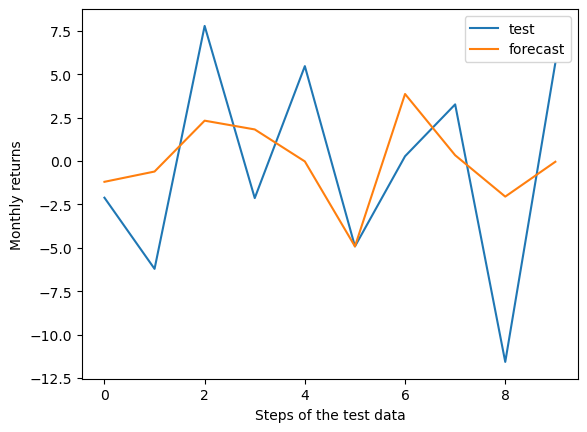

r2_score:  0.25065133826183883
rmse:  5.025422861316501
description:  count    114.000000
mean       2.248562
std       12.696066
min      -39.516129
25%       -4.629741
50%        2.567766
75%        8.026326
max       43.243243
Name: returns, dtype: float64


In [13]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=ucap_end_month_df['returns'].dropna()[:-10]
y_test=ucap_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,0,0), 
seasonal_order=(0,0,1,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', ucap_end_month_df.returns.dropna().describe())

Much better.
